In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from collections import Counter
import json
import ast

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import RFECV, RFE
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from quantile_forest import RandomForestQuantileRegressor

from skopt import BayesSearchCV
from skopt.space import Integer, Real
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import linregress, t
from scipy.stats import f_oneway
from cProfile import label
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

In [5]:
# merge tables
df = pd.read_csv("20241111_ck_all.csv")
df["SiteID"] = df["SiteID"].astype(str)
df_moisture = pd.read_csv("20241024_ck_soilMoisture.csv")
df_merge = pd.merge(df, df_moisture, on="SiteID", how='left')
df_merge.to_csv("merge.csv", index=False)

C:\Users\zhou.tang\AppData\Local\Temp\ipykernel_38900\548464801.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("20241111_ck_all.csv")


In [6]:
df_grz = pd.read_csv("20241118_newfeatures.csv")
df_merge = pd.merge(df_merge, df_grz, on="SiteID", how='left')
df_merge.to_csv("merge.csv", index=False)

In [9]:
df_buffer1 = pd.read_csv("buffer_10_clean.csv")
df_merge = pd.merge(df_merge, df_buffer1, on="SiteID", how='left')
df_merge.to_csv("merge.csv", index=False)

In [18]:
# remove raw with NaN value
data = pd.read_csv("20241121_allX_reorg.csv")
print(data.shape)
print("===")
data= data[data["is_label_issue_LULC"]==False]
print(data.shape)
data = data[~data["SOC (t/ha)_20cm_convert"].isna()]
print(data.shape)
data = data[~data["band_1_buffer10"].isna()]
print(data.shape)
data = data[~data["SoilMoisture01"].isna()]
print(data.shape)
data = data[~data["grazing_density"].isna()]
print(data.shape)
data = data[~data["wc2.1_30s_bio_1"].isna()]
print(data.shape)
data.to_csv("20241121_allX_reorg_clean.csv", index=False)

C:\Users\zhou.tang\AppData\Local\Temp\ipykernel_38900\1125904495.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("20241121_allX_reorg.csv")


(1190, 712)
===
(1079, 712)
(1072, 712)
(1070, 712)
(1068, 712)
(1049, 712)
(1047, 712)


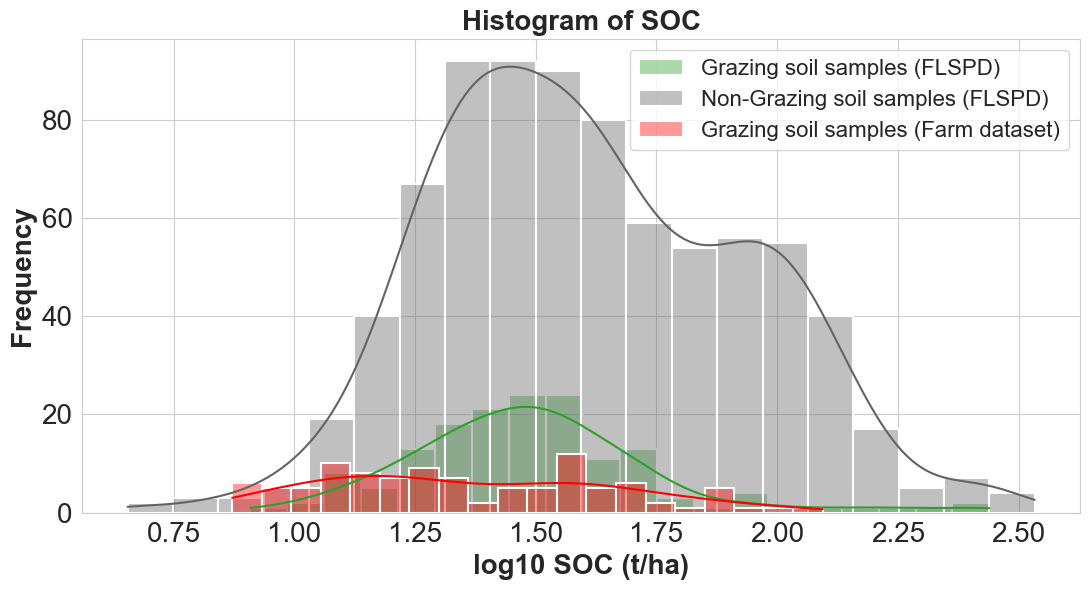

In [22]:
# Step 2: Define custom legend labels (Modify as needed)
legend_map = {
    "FLSPD_grazing": "Grazing soil samples (FLSPD)",
    "FLSPD_No_graz": "Non-Grazing soil samples (FLSPD)",
    "Cattle Farm_grazing": "Grazing soil samples (Farm dataset)"
}

legend_col = {
    "FLSPD_grazing": '#2ca02c',
    "FLSPD_No_graz": '#636363',  # Red
    "Cattle Farm_grazing": "red",
    # "FLSPD": "#2c7fb8"  # dimgray is a good approximation for black gray
}



# Load the CSV file
df = pd.read_csv("./01_after_cluster.csv")

# Create a new column combining Class_A and Class_B
df["Combined_Class"] = df["data_source"].astype(str) + "_" + df["Gtype_inter"].astype(str)

# Set style for professional look
sns.set_style("whitegrid")

# Create histogram plots
plt.figure(figsize=(11, 6))

# Loop through each unique class combination and plot histogram
for class_name in df["Combined_Class"].unique():
    subset = df[df["Combined_Class"] == class_name]
    # sns.histplot(np.log10(subset['SOC (t/ha)']), bins=20, kde=True, label=class_name, alpha=0.6)

    sns.histplot(np.log10(subset['SOC (t/ha)']), bins=20, kde=True, color=legend_col.get(class_name, class_name), label=legend_map.get(class_name, class_name), alpha=0.4, linewidth=1.5)



# Formatting the plot

# Formatting
plt.xlabel("log10 SOC (t/ha)", fontsize=20, fontweight='bold')
plt.ylabel("Frequency", fontsize=20, fontweight='bold')
plt.title("Histogram of SOC", fontsize=20, fontweight='bold')
plt.legend(fontsize=16, title_fontsize=20, loc='upper right')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()


In [7]:
df = pd.read_csv("./01_after_cluster.csv")
# df
# Group by "type" and calculate statistics for "y"
# summary = df.groupby("data_source")["SOC (t/ha)"].agg(["mean", "std", "max", "" ,"min"]).reset_index()

# # Rename columns for clarity
# summary.columns = ["data_source", "Average", "StdDev", "Max", "Median","Min",]

# # Print the summary table
# print(summary)

# Summary statistics for SOC grouped by source
summary = df.groupby("data_source")["SOC (t/ha)"].agg(
    Mean="mean",
    StdDev="std",
    Max="max",
    Median="median",
    Min="min",
    Count="count"
)

# Calculate Coefficient of Variation (CV = std / mean * 100)
summary["CV (%)"] = (summary["StdDev"] / summary["Mean"]) * 100

# Display the summary
print(summary)
summary.to_csv("./SOC_summary_2.csv", index=True)

                  Mean     StdDev         Max     Median       Min  Count  \
data_source                                                                 
Cattle Farm  29.228691  22.301357  124.246501  20.476675  7.434702    103   
FLSPD        51.559927  45.152191  341.457651  35.111419  4.515352    944   

                CV (%)  
data_source             
Cattle Farm  76.299539  
FLSPD        87.572257  


In [6]:
# Create a new column by combining class columns A and B
df["Combined_Class"] = df["data_source"].astype(str) + "_" + df["Gtype_inter"].astype(str)

# Group by the combined class and calculate statistics for "y"
summary = df.groupby("Combined_Class")["SOC (t/ha)"].agg(
    Mean="mean",
    StdDev="std",
    Max="max",
    Median="median",
    Min="min",
    Count="count"
)

# Rename columns for clarity
summary["CV (%)"] = (summary["StdDev"] / summary["Mean"]) * 100

# Print the summary table
print(summary)
summary.to_csv("./SOC_summary.csv", index=True)

                          Mean     StdDev         Max     Median       Min  \
Combined_Class                                                               
Cattle Farm_grazing  29.228691  22.301357  124.246501  20.476675  7.434702   
FLSPD_No_graz        54.092061  46.004423  341.457651  37.544518  4.515352   
FLSPD_grazing        38.570404  38.059031  275.241062  30.497823  8.107799   

                     Count     CV (%)  
Combined_Class                         
Cattle Farm_grazing    103  76.299539  
FLSPD_No_graz          790  85.048382  
FLSPD_grazing          154  98.674182  


In [15]:
summary = df.groupby("cropLandcover")["SOC (t/ha)"].agg(["mean", "max", "min", "std", "count"]).reset_index()
# Rename columns for clarity
summary.columns = ["cropLandcover", "Average", "Max", "Min", "StdDev", "Count"]
# Print the summary table
print(summary)

    cropLandcover     Average         Max        Min     StdDev  Count
0               1   28.879363   42.218150   9.191074  10.149829      9
1               2   31.110214   52.946352  18.728182  13.116539      5
2              10   25.534308   51.508072  16.096266  11.222679     10
3              27   20.589677   20.589677  20.589677        NaN      1
4              28   19.461435   19.461435  19.461435        NaN      1
5              29    8.336949    9.181572   7.492325   1.194478      2
6              37   32.817398  101.999800   7.434702  24.801014     34
7              43   13.186070   13.186070  13.186070        NaN      1
8              45  227.400472  341.457651  34.596999  83.870979     17
9              48   11.345368   11.345368  11.345368        NaN      1
10             59   16.796376   21.426492   9.403222   6.470358      3
11             61   30.518982   61.314268  20.178368  14.529661      7
12             72   22.171431   30.053914  15.128161   7.606572      4
13    

In [16]:
summary = df.groupby("landcover")["SOC (t/ha)"].agg(["mean", "max", "min", "std", "count"]).reset_index()
# Rename columns for clarity
summary.columns = ["landcover", "Average", "Max", "Min", "StdDev", "Count"]
# Print the summary table
print(summary)

    landcover    Average         Max        Min     StdDev  Count
0          11   8.280986    8.280986   8.280986        NaN      1
1          21  40.008191  143.668980   7.904094  26.464854    144
2          22  34.583623  258.344469  10.124733  30.861133     72
3          23  39.023354  118.158086   4.570194  22.707625     25
4          24  68.116173  137.686387  37.545778  46.892024      4
5          42  36.397423  142.032793   5.990340  24.938011    198
6          43  52.464817  127.314512  22.057271  43.573913      5
7          52  24.542943   52.719480   6.531247  11.326221     37
8          71  39.951330  155.096266   8.303540  46.036597     14
9          81  36.647565  220.730070   7.909618  25.264917    167
10         82  64.869709  341.457651   7.434702  90.306462     92
11         90  66.889620  246.245746   6.902116  42.251454    200
12         95  88.330614  171.231200   4.515352  38.883488     88


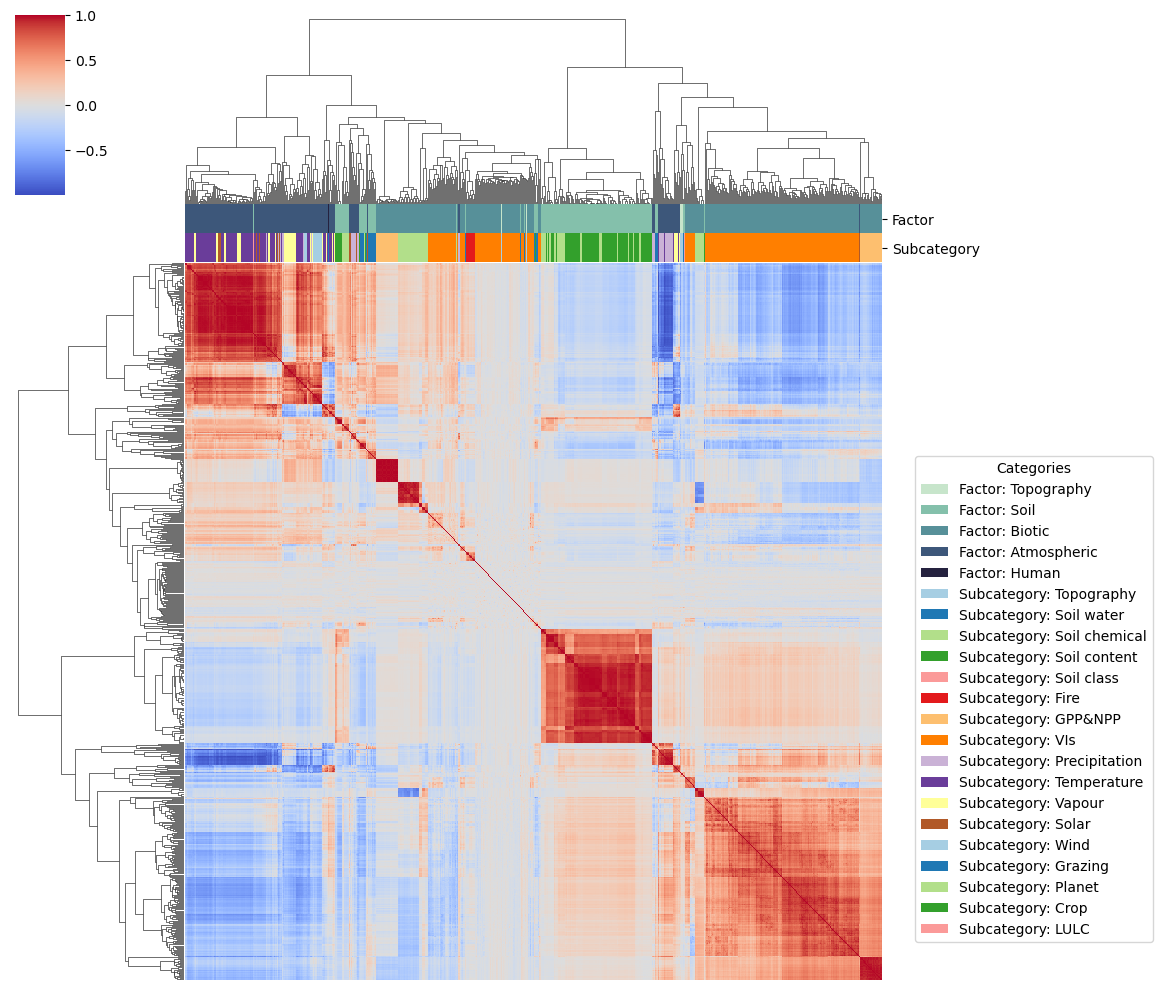

In [60]:

df = pd.read_csv("20241121_allX_reorg_clean.csv")
A = df.loc[:,"elevation_10m":"NDRE_buffer10"]
correlation_matrix = A.corr(method='pearson')
B = pd.read_csv("20241121_allX_reorg_varName.csv")

category1_colors = dict(zip(B["Factor"].unique(), sns.color_palette("ch:s=.25,rot=-.5", n_colors=len(B["Factor"].unique()))))
category2_colors = dict(zip(B["Subcategory"].unique(), sns.color_palette("Paired", n_colors=len(B["Subcategory"].unique()))))

B["Category I Color"] = B["Factor"].map(category1_colors)
B["Category II Color"] = B["Subcategory"].map(category2_colors)

col_colors = pd.DataFrame({
    "Factor": B["Category I Color"].tolist(),
    "Subcategory": B["Category II Color"].tolist(),
}, index=B["Var"])

# Step 3: Create clustermap
sns.clustermap(correlation_matrix, col_colors=col_colors, cmap="coolwarm", center=0,  xticklabels=False,  yticklabels=False)

# Step 4: Add legends for the color annotations
legend_handles = []

# Add Category I legend
for category, color in category1_colors.items():
    legend_handles.append(Patch(facecolor=color, label=f"Factor: {category}"))

# Add Category II legend
for category, color in category2_colors.items():
    legend_handles.append(Patch(facecolor=color, label=f"Subcategory: {category}"))

# Place the legend
plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(18, -2.8),  # Position outside the plot
    loc='center left',
    borderaxespad=0,
    title="Categories",
)

# Display the plot
plt.show()


In [57]:
# feature selection
df = pd.read_csv("20241121_allX_reorg_clean.csv")
A = df.loc[:,"elevation_10m":"NDRE_buffer10"]
corr_matrix = A.corr(method='pearson')

# Convert the correlation matrix to a distance matrix (1 - correlation)
distance_matrix = 1 - corr_matrix.abs()

# Perform hierarchical clustering
# The UPGMA (unweighted pair group method with arithmetic mean) algorithm for average here.
linked = linkage(squareform(distance_matrix), method='average')

# Cut the dendrogram at a certain threshold to form flat clusters
# You can adjust the 't' value to control the number of clusters
clusters = fcluster(linked, t=0.2, criterion='distance')

# Create a DataFrame to show the variable and its corresponding cluster
cluster_df = pd.DataFrame({'Variable': A.columns, 'Cluster': clusters})
cluster_df_sorted = cluster_df.sort_values(by='Cluster').reset_index(drop=True)

cluster_df_sorted.to_csv("./cluster_0.2_sorted.csv")
cluster_df.to_csv("./cluster_0.2.csv")


In [208]:
a = ['GPP_2001','GPP_2011']
df


,SiteID,Gtype_inter,data_source,data_source_cls,is_label_issue_LULC,Longitude,Latitude,SOC (t/ha),evi_oct_0307_kurt,ndvi_dec_0307_kurt,...,ndvi_apr_0307_skew,evi_mar_0307_skew,evi_apr_0307_skew,Lookup_Soil_Taxnomy_Order,Lookup_Soil_Taxonomy_Great_Group,Lookup_Soil_Taxonomy_Subo,Lookuo_Soil_Taxonomy_Particle_Si,Lookup_Hydrologic_Soil_Group,cropLandcover,landcover
0,1,grazing,Historical,sabine,False,-81.609557,27.159316,220.730070,-0.000289,-0.000180,...,-4.590000e-05,0.000045,-0.000178,5,9,8,5,1,176,81
1,2,No_graz,Historical,sabine,False,-81.587935,27.602949,148.488841,-0.000168,-0.000150,...,-5.940000e-05,0.000006,-0.000036,5,9,8,1,4,190,95
2,8,No_graz,Historical,sabine,False,-85.016630,30.081984,44.196776,-0.000247,0.000279,...,-6.330000e-05,-0.000062,0.000038,1,4,4,9,3,121,42
3,9,No_graz,Historical,sabine,False,-85.306678,30.398066,25.830273,0.000140,0.000044,...,-9.540000e-06,0.000023,-0.000011,1,1,1,1,1,121,21
4,16,No_graz,Historical,sabine,False,-85.247085,30.066047,24.605654,0.000243,0.000184,...,1.239770e-04,0.000176,0.000026,1,1,1,9,8,142,42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,c93,grazing,Cattle Farm,cattle,False,-80.379836,27.134083,20.476675,0.000167,0.000215,...,1.300000e-05,0.000021,-0.000026,3,3,3,3,4,121,21
1043,c94,grazing,Cattle Farm,cattle,False,-80.847116,27.990080,9.118443,0.000353,-0.000319,...,1.120000e-07,-0.000099,-0.000022,4,17,5,1,4,212,82
1044,c96,grazing,Cattle Farm,cattle,False,-80.836403,27.982802,12.121062,-0.000008,-0.000059,...,-4.470000e-05,0.000057,0.000008,4,17,5,1,4,212,82
1045,c98,grazing,Cattle Farm,cattle,False,-80.887188,28.045184,37.816285,0.000185,-0.000001,...,4.030000e-05,0.000064,0.000023,3,3,3,3,1,152,90


In [222]:
# use the VIF to remove feature from each cluster
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Function to process clusters and reduce features based on VIF
def reduce_features_by_cluster(A, B, vif_threshold=10):
    """
    Parameters:
        A (pd.DataFrame): Feature DataFrame where columns are features.
        B (pd.DataFrame): DataFrame with two columns: 'feature' and 'cluster'.
                          'feature' contains feature names in A.
                          'cluster' contains cluster IDs for each feature.
        vif_threshold (float): Optional threshold for VIF to stop early. Default is inf (no threshold).
    Returns:
        pd.DataFrame: Reduced DataFrame with one feature per cluster.
    """
    # Initialize the result DataFrame
    reduced_features = []
    
    # Iterate over unique clusters
    for cluster_id in B['Cluster'].unique():
        # Get features in the current cluster
        cluster_features = B[B['Cluster'] == cluster_id]['Var']
        cluster_data = A[cluster_features]
        
        # If the cluster has more than 2 features, apply VIF reduction
        while cluster_data.shape[1] > 1:
            vif_data = calculate_vif(cluster_data)
            
            # Check if all VIF values are below the threshold
            if vif_data['VIF'].max() < vif_threshold:
                break
            
            # Remove the feature with the highest VIF
            feature_to_remove = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
            cluster_data = cluster_data.drop(columns=[feature_to_remove])
            # print(f"Cluster {cluster_id}: Removing feature {feature_to_remove} with VIF={vif_data['VIF'].max()}")
        
        # Keep the remaining feature(s) in the cluster
        reduced_features.extend(cluster_data.columns)
    
    # Return the reduced DataFrame
    # return A[reduced_features]
    return reduced_features


# Function to process clusters and reduce features based on VIF
def reduce_features_by_cluster_with_tracking(A, B, vif_threshold=10):
    """
    Parameters:
        A (pd.DataFrame): Feature DataFrame where columns are features.
        B (pd.DataFrame): DataFrame with two columns: 'feature' and 'cluster'.
                          'feature' contains feature names in A.
                          'cluster' contains cluster IDs for each feature.
        vif_threshold (float): Optional threshold for VIF to stop early. Default is inf (no threshold).
    Returns:
        pd.DataFrame: Updated B with 'status' column indicating 'keep' or 'delete'.
        pd.DataFrame: Reduced DataFrame with one feature per cluster.
    """
    # Add a new column in B for tracking
    B = B.copy()
    B['status'] = 'keep'  # Default all features to 'keep'

    # Iterate over unique clusters
    for cluster_id in B['Cluster'].unique():
        # Get features in the current cluster
        cluster_features = B[B['Cluster'] == cluster_id]['Var']
        cluster_data = A[cluster_features]
        
        # If the cluster has more than 2 features, apply VIF reduction
        while cluster_data.shape[1] > 1:
            vif_data = calculate_vif(cluster_data)
            
            # Check if all VIF values are below the threshold
            if vif_data['VIF'].max() < vif_threshold:
                break
            
            # Remove the feature with the highest VIF
            feature_to_remove = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
            cluster_data = cluster_data.drop(columns=[feature_to_remove])
            
            # Update the status in B to 'delete'
            B.loc[B['Var'] == feature_to_remove, 'status'] = 'delete'
            # print(f"Cluster {cluster_id}: Removing feature {feature_to_remove} with VIF={vif_data['VIF'].max()}")
        
        # Keep the remaining feature(s) in the cluster (if more than one left, no further action needed)
        for remaining_feature in cluster_data.columns:
            B.loc[B['Var'] == remaining_feature, 'status'] = 'keep'

    # Create reduced DataFrame
    reduced_features = B[B['status'] == 'keep']['Var']
    reduced_A = A[reduced_features]

    return B, reduced_A


df = pd.read_csv("00_20241121_allX_reorg_clean.csv")
cluster_df_sorted = pd.read_csv("00_cluster_0.2_sorted.csv")
# reduced_A = reduce_features_by_cluster(A=df, B=cluster_df_sorted)
# reduced_features = reduce_features_by_cluster(A=df, B=cluster_df_sorted)


B_updated, reduced_A = reduce_features_by_cluster_with_tracking(A, B)
print("Updated B with 'status':")
print(B_updated)
print("\nReduced DataFrame:")
print(reduced_A)
B_updated.to_csv("00_reduce_cluster_by_VIF.csv", index=False)

Updated B with 'status':
     Idx                 Var  Factor Subcategory  Cluster Select status
0      1   evi_oct_0307_kurt  Biotic         VIs        1   keep   keep
1      2  ndvi_dec_0307_kurt  Biotic         VIs        2   keep   keep
2      3  ndvi_jul_0307_skew  Biotic         VIs        3   keep   keep
3      4  ndvi_jul_0307_kurt  Biotic         VIs        4   keep   keep
4      5   evi_jul_0307_skew  Biotic         VIs        5   keep   keep
..   ...                 ...     ...         ...      ...    ...    ...
692  693  ndvi_feb_0307_skew  Biotic         VIs      200   keep   keep
693  694  ndvi_mar_0307_skew  Biotic         VIs      201   keep   keep
694  695  ndvi_apr_0307_skew  Biotic         VIs      202   keep   keep
695  696   evi_mar_0307_skew  Biotic         VIs      203   keep   keep
696  697   evi_apr_0307_skew  Biotic         VIs      204   keep   keep

[697 rows x 7 columns]

Reduced DataFrame:
      evi_oct_0307_kurt  ndvi_dec_0307_kurt  ndvi_jul_0307_skew  \


In [360]:
A = pd.read_csv("00_20241121_allX_reorg_clean.csv")
B = pd.read_csv("00_reduce_cluster_by_VIF.csv")
# Step 1: Filter columns in A based on B['select'] == 'keep'
# columns_to_keep = B.loc[B['status_vif'] == 'keep', 'Var']
columns_to_keep = B.loc[B['status_vif'] == 'keep', 'Var']
# Step 2: Identify columns in A that are not listed in B
first_cols = A.columns[:8]
last_cols = A.columns[-9:]
print(first_cols)
print(last_cols)
# # Step 3: Combine the columns to keep
final_columns = pd.Index(list(first_cols) + list(columns_to_keep) + list(last_cols))
# Step 4: Subset A with the final columns
A_filtered = A[final_columns]
# Output the result
A_filtered.to_csv("./01_after_cluster.csv", index=False)


Index(['SiteID', 'Gtype_inter', 'data_source', 'data_source_cls',
       'is_label_issue_LULC', 'Longitude', 'Latitude', 'SOC (t/ha)'],
      dtype='object')
Index(['Lookup_Soil_Taxnomy_Order', 'Lookup_Soil_Taxonomy_Great_Group',
       'Lookup_Soil_Taxonomy_Subo', 'Lookuo_Soil_Taxonomy_Particle_Si',
       'Lookup_Hydrologic_Soil_Group', 'cropLandcover', 'landcover',
       'Level4_Ecoregions_FL', 'Surficial_Geology_of_Florida'],
      dtype='object')


In [366]:
# nested cross validation with rfe
from random import random

data= pd.read_csv("./01_after_cluster.csv")
data = data[data["data_source"]=="FLSPD"]
data = data[(data["Gtype_inter"]=="grazing")]
data = data.reset_index(drop=True)

y = data["SOC (t/ha)"]
X = data.loc[:, "evi_oct_0307_kurt": ]

# # Prepare Cross-Validation
n_splits = 5
# quantiles = [0.025, 0.05, 0.1, 0.5, 0.9, 0.95, 0.975]
quantiles = np.arange(0, 1.01, 0.01).tolist()
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []

# Define BayesSearchCV parameter grid
param_grid = {
    "n_estimators": Integer(50, 600),
    "max_depth": Integer(5, 50),
    "min_samples_split": Integer(2, 20),
    "min_samples_leaf": Integer(1, 5),
    "max_features": Real(0.1, 1.0, "uniform")
}

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    print(f"Processing fold {fold}/{n_splits}")
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train_num = X_train.loc[:, "evi_oct_0307_kurt": "evi_apr_0307_skew"]
    X_train_cate = X_train.loc[:, "Lookup_Soil_Taxnomy_Order": ]

    X_test_num = X_test.loc[:, "evi_oct_0307_kurt": "evi_apr_0307_skew"]
    X_test_cate = X_test.loc[:, "Lookup_Soil_Taxnomy_Order": ]
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_num)

    # Initial Feature Selection with RFE
    print("start feature selection with RFE")
    lin_reg = LinearRegression()
    inner_kf = KFold(n_splits=5, shuffle=True, random_state=12)
    rfecv = RFECV(estimator=lin_reg, step=1, cv=inner_kf, scoring="r2", min_features_to_select=50)
    rfecv.fit(X_train_scaled, y_train)

    # Get selected features from RFE
    X_train_rfe = X_train_num.iloc[:, rfecv.support_]
    print(f"after RFE, {X_train_rfe.shape} left")
    X_train_rfe = pd.concat([X_train_rfe, X_train_cate], axis=1)
    print(f"after adding category variables, {X_train_rfe.shape} left")

    X_test_rfe = X_test_num.iloc[:, rfecv.support_]
    X_test_rfe = pd.concat([X_test_rfe , X_test_cate], axis=1)
    
    # Hyperparameter Optimization with BayesSearchCV
    print("start parameter searching")
    bayes_search = BayesSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        search_spaces=param_grid,
        n_iter=20,
        cv=3,
        scoring="r2",
        n_jobs=-1,
        random_state=42
    )
    bayes_search.fit(X_train_rfe, y_train)
    best_params = bayes_search.best_params_

    # Train the model with best parameters
    best_model = bayes_search.best_estimator_
    best_model.fit(X_train_rfe, y_train)

    # Evaluate performance
    y_train_pred = best_model.predict(X_train_rfe)
    y_test_pred = best_model.predict(X_test_rfe)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
    test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

    data.loc[test_idx, 'Predicted'] = y_test_pred
    data.loc[test_idx, "fold"] = f"{fold}"

    # quantile RandomForestRegressor
    rf_quantile = RandomForestQuantileRegressor(random_state=42, n_estimators=best_params["n_estimators"], max_depth=best_params["max_depth"], \
                                                max_features=best_params["max_features"], min_samples_leaf=best_params["min_samples_leaf"], min_samples_split=best_params["min_samples_split"])
    rf_quantile.fit(X_train_rfe, y_train)

    # percentiles = quantiles
    predictions = rf_quantile.predict(X_test_rfe, quantiles=quantiles)

    # Step 11: Predict on the test set
    for i, q in enumerate(quantiles):
        data.loc[test_idx, f'pre_{q * 100}th'] = predictions[:,i]


    # Store results for each fold
    results.append({
        "fold": fold,
        "selected_features": X_train_rfe.columns.tolist(),
        "best_params": best_params,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse
    })

# Display results for each fold
results_df = pd.DataFrame(results)
results_df["best_params"] = results_df["best_params"].apply(json.dumps)
print(results_df)

# results_df.to_csv("./02_nestedCV_feature_selection_all.csv", index=False)
# data.to_csv("./03_nestedCV_prediction_all.csv", index=False)

# results_df.to_csv("./02_nestedCV_feature_selection_sabine.csv", index=False)
# data.to_csv("./03_nestedCV_prediction_sabine.csv", index=False)

# results_df.to_csv("./02_nestedCV_feature_selection_all_grazing.csv", index=False)
# data.to_csv("./03_nestedCV_prediction_all_grazing.csv", index=False)

results_df.to_csv("./02_nestedCV_feature_selection_sabine_grazing.csv", index=False)
data.to_csv("./03_nestedCV_prediction_sabine_grazing.csv", index=False)


Processing fold 1/5
start feature selection with RFE
after RFE, (123, 121) left
after adding category variables, (123, 130) left
start parameter searching
Processing fold 2/5
start feature selection with RFE
after RFE, (123, 166) left
after adding category variables, (123, 175) left
start parameter searching
Processing fold 3/5
start feature selection with RFE
after RFE, (123, 166) left
after adding category variables, (123, 175) left
start parameter searching
Processing fold 4/5
start feature selection with RFE
after RFE, (123, 154) left
after adding category variables, (123, 163) left
start parameter searching
Processing fold 5/5
start feature selection with RFE
after RFE, (124, 116) left
after adding category variables, (124, 125) left
start parameter searching
   fold                                  selected_features  \
0     1  [evi_oct_0307_kurt, ndvi_dec_0307_kurt, ndvi_j...   
1     2  [evi_oct_0307_kurt, ndvi_dec_0307_kurt, ndvi_j...   
2     3  [evi_oct_0307_kurt, ndvi_jul_0

R-squared for all: 0.6459265222278371
R-squared for all with function r2_score in : 0.6312575451801679
RMSE for all is 19.962282203519464


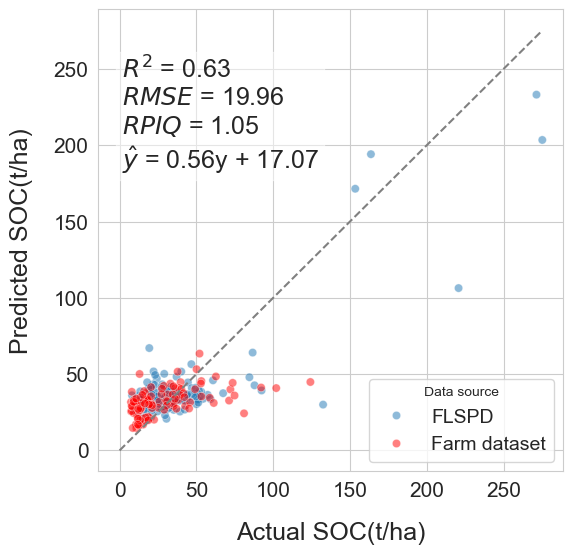

In [5]:
# visualize the plot
df_pre = pd.read_csv(f"./03_nestedCV_prediction_all.csv")
row_graz = df_pre[(df_pre["Gtype_inter"]=="grazing")]
y_true_all = row_graz['SOC (t/ha)']
y_pre_all = row_graz['Predicted']
r_squared = np.corrcoef(y_true_all, y_pre_all)[0, 1]**2  # Calculate R-squared value
print(f"R-squared for all:", r_squared)
r_2_score = r2_score(y_true_all, y_pre_all)
print(f"R-squared for all with function r2_score in :", r_2_score)

mse = mean_squared_error(y_true_all, y_pre_all)
rmse = np.sqrt(mse)
print(f"RMSE for all is {rmse}")

iqr = np.percentile(y_true_all, 75) - np.percentile(y_true_all, 25)
rpiq = iqr / rmse

plt.figure(figsize=(6, 6))
custom_palette = {
    'Cattle Farm': 'red',
    'FLSPD': '#1f77b4',
}

custom_labels = {
    'Cattle Farm': 'Farm dataset',
    'FLSPD': 'FLSPD',
}

ax = sns.scatterplot(x='SOC (t/ha)', y='Predicted', hue='data_source', data=row_graz,palette=custom_palette, alpha=0.5)
handles, labels = ax.get_legend_handles_labels()
new_labels = [custom_labels[label] for label in labels[:]]
ax.legend(handles[:], new_labels, title='Data source', loc=4, fontsize=14)
plt.xlabel('Actual SOC(t/ha)',fontsize=18, labelpad=15)
plt.ylabel('Predicted SOC(t/ha)',fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
sns.set_style("whitegrid")

# Calculate regression line
slope, intercept, r_value, p_value, std_err = linregress(y_true_all, y_pre_all)
trendline = slope * y_true_all + intercept

# Add reference line (y=x)
plt.plot([0, y_true_all.max()], [0, y_true_all.max()], color="gray", linestyle="--", label="Reference Line")

equation = f"$R^2$ = {r_2_score:.2f} \n$RMSE$ = {rmse:.2f} \n$RPIQ$ = {rpiq:.2f} \n$\hat{{y}}$ = {slope:.2f}y + {intercept:.2f}"
plt.text(0.05, 0.9, equation, transform=plt.gca().transAxes, fontsize=18, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

R-squared for all: 0.723626874110352
R-squared for all with function r2_score in : 0.6949180730693547
RMSE for all is 20.95324646800894


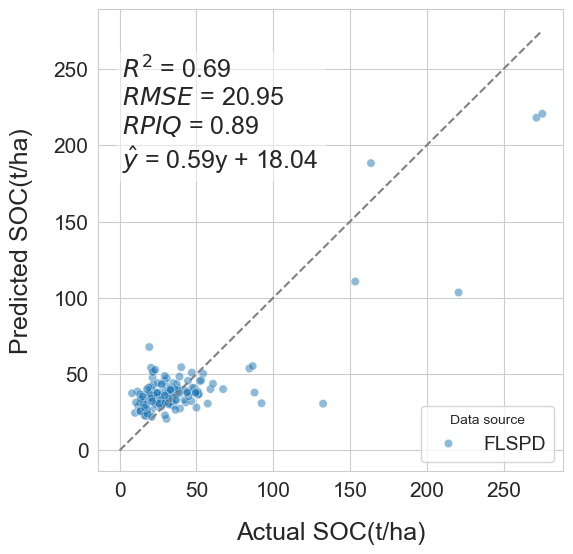

In [6]:
# visualize the plot
df_pre = pd.read_csv(f"./03_nestedCV_prediction_sabine.csv")
row_graz = df_pre[(df_pre["Gtype_inter"]=="grazing")]
y_true_all = row_graz['SOC (t/ha)']
y_pre_all = row_graz['Predicted']
r_squared = np.corrcoef(y_true_all, y_pre_all)[0, 1]**2  # Calculate R-squared value
print(f"R-squared for all:", r_squared)
r_2_score = r2_score(y_true_all, y_pre_all)
print(f"R-squared for all with function r2_score in :", r_2_score)

iqr = np.percentile(y_true_all, 75) - np.percentile(y_true_all, 25)
rpiq = iqr / rmse

mse = mean_squared_error(y_true_all, y_pre_all)
rmse = np.sqrt(mse)
print(f"RMSE for all is {rmse}")

plt.figure(figsize=(6, 6))
custom_palette = {
    'Cattle Farm': 'red',
    'FLSPD': '#1f77b4',
}

custom_labels = {
    'Cattle Farm': 'Farm dataset',
    'FLSPD': 'FLSPD',
}

ax = sns.scatterplot(x='SOC (t/ha)', y='Predicted', hue='data_source', data=row_graz,palette=custom_palette, alpha=0.5)
handles, labels = ax.get_legend_handles_labels()
new_labels = [custom_labels[label] for label in labels[:]]
ax.legend(handles[:], new_labels, title='Data source', loc=4, fontsize=14)
plt.xlabel('Actual SOC(t/ha)',fontsize=18, labelpad=15)
plt.ylabel('Predicted SOC(t/ha)',fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
sns.set_style("whitegrid")

# Calculate regression line
slope, intercept, r_value, p_value, std_err = linregress(y_true_all, y_pre_all)
trendline = slope * y_true_all + intercept

# Add reference line (y=x)
plt.plot([0, y_true_all.max()], [0, y_true_all.max()], color="gray", linestyle="--", label="Reference Line")

equation = f"$R^2$ = {r_2_score:.2f} \n$RMSE$ = {rmse:.2f} \n$RPIQ$ = {rpiq:.2f}  \n$\hat{{y}}$ = {slope:.2f}y + {intercept:.2f}"
plt.text(0.05, 0.9, equation, transform=plt.gca().transAxes, fontsize=18, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

R-squared for all: 0.6593586498301758
R-squared for all with function r2_score in : 0.6028253967916543
RMSE for all is 23.907480834980074


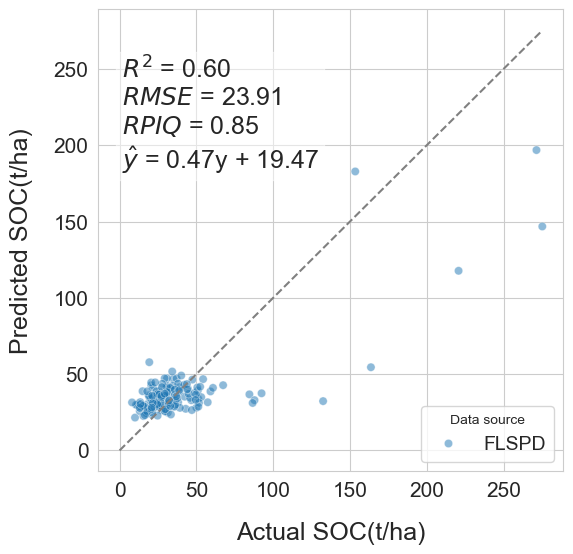

In [7]:
# visualize the plot
df_pre = pd.read_csv(f"./03_nestedCV_prediction_sabine_grazing.csv")
row_graz = df_pre[(df_pre["Gtype_inter"]=="grazing")]
y_true_all = row_graz['SOC (t/ha)']
y_pre_all = row_graz['Predicted']
r_squared = np.corrcoef(y_true_all, y_pre_all)[0, 1]**2  # Calculate R-squared value
print(f"R-squared for all:", r_squared)
r_2_score = r2_score(y_true_all, y_pre_all)
print(f"R-squared for all with function r2_score in :", r_2_score)

iqr = np.percentile(y_true_all, 75) - np.percentile(y_true_all, 25)
rpiq = iqr / rmse

mse = mean_squared_error(y_true_all, y_pre_all)
rmse = np.sqrt(mse)
print(f"RMSE for all is {rmse}")

plt.figure(figsize=(6, 6))
custom_palette = {
    'Cattle Farm': 'red',
    'FLSPD': '#1f77b4',
}

custom_labels = {
    'Cattle Farm': 'Farm dataset',
    'FLSPD': 'FLSPD',
}

ax = sns.scatterplot(x='SOC (t/ha)', y='Predicted', hue='data_source', data=row_graz,palette=custom_palette, alpha=0.5)
handles, labels = ax.get_legend_handles_labels()
new_labels = [custom_labels[label] for label in labels[:]]
ax.legend(handles[:], new_labels, title='Data source', loc=4, fontsize=14)
plt.xlabel('Actual SOC(t/ha)',fontsize=18, labelpad=15)
plt.ylabel('Predicted SOC(t/ha)',fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
sns.set_style("whitegrid")

# Calculate regression line
slope, intercept, r_value, p_value, std_err = linregress(y_true_all, y_pre_all)
trendline = slope * y_true_all + intercept

# Add reference line (y=x)
plt.plot([0, y_true_all.max()], [0, y_true_all.max()], color="gray", linestyle="--", label="Reference Line")

equation = f"$R^2$ = {r_2_score:.2f} \n$RMSE$ = {rmse:.2f} \n$RPIQ$ = {rpiq:.2f} \n$\hat{{y}}$ = {slope:.2f}y + {intercept:.2f}"
plt.text(0.05, 0.9, equation, transform=plt.gca().transAxes, fontsize=18, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

R-squared for all: 0.5241342000518499
R-squared for all with function r2_score in : 0.4615427556183648
RMSE for all is 24.122606458399243


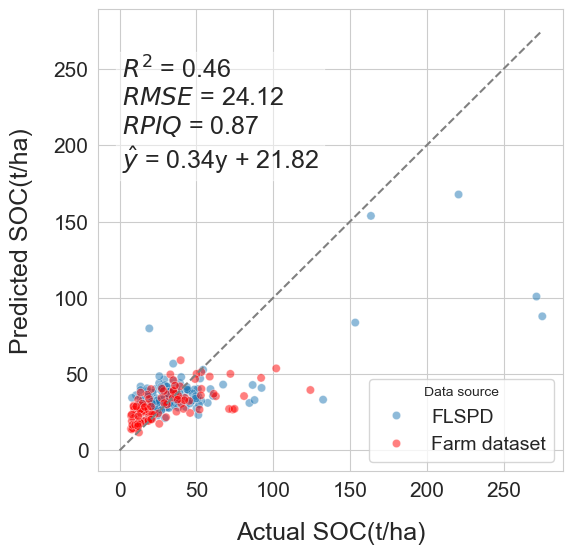

In [8]:
# visualize the plot
df_pre = pd.read_csv(f"./03_nestedCV_prediction_all_grazing.csv")
row_graz = df_pre[(df_pre["Gtype_inter"]=="grazing")]
y_true_all = row_graz['SOC (t/ha)']
y_pre_all = row_graz['Predicted']
r_squared = np.corrcoef(y_true_all, y_pre_all)[0, 1]**2  # Calculate R-squared value
print(f"R-squared for all:", r_squared)
r_2_score = r2_score(y_true_all, y_pre_all)
print(f"R-squared for all with function r2_score in :", r_2_score)

mse = mean_squared_error(y_true_all, y_pre_all)
rmse = np.sqrt(mse)
print(f"RMSE for all is {rmse}")

iqr = np.percentile(y_true_all, 75) - np.percentile(y_true_all, 25)
rpiq = iqr / rmse

plt.figure(figsize=(6, 6))
custom_palette = {
    'Cattle Farm': 'red',
    'FLSPD': '#1f77b4',
}

custom_labels = {
    'Cattle Farm': 'Farm dataset',
    'FLSPD': 'FLSPD',
}

ax = sns.scatterplot(x='SOC (t/ha)', y='Predicted', hue='data_source', data=row_graz,palette=custom_palette, alpha=0.5)
handles, labels = ax.get_legend_handles_labels()
new_labels = [custom_labels[label] for label in labels[:]]
ax.legend(handles[:], new_labels, title='Data source', loc=4, fontsize=14)
plt.xlabel('Actual SOC(t/ha)',fontsize=18, labelpad=15)
plt.ylabel('Predicted SOC(t/ha)',fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
sns.set_style("whitegrid")

# Calculate regression line
slope, intercept, r_value, p_value, std_err = linregress(y_true_all, y_pre_all)
trendline = slope * y_true_all + intercept

# Add reference line (y=x)
plt.plot([0, y_true_all.max()], [0, y_true_all.max()], color="gray", linestyle="--", label="Reference Line")

equation = f"$R^2$ = {r_2_score:.2f} \n$RMSE$ = {rmse:.2f} \n$RPIQ$ = {rpiq:.2f} \n$\hat{{y}}$ = {slope:.2f}y + {intercept:.2f}"
plt.text(0.05, 0.9, equation, transform=plt.gca().transAxes, fontsize=18, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.grid(True)
plt.show()

(1047, 335)
(257, 335)
====
start is 0 quantile is 0.0, end is 100, quantile is 1.0
interval is 1.0, portion is 0.9688715953307393
====
start is 1 quantile is 0.01, end is 99, quantile is 0.99
interval is 0.98, portion is 0.9571984435797666
====
start is 2 quantile is 0.02, end is 98, quantile is 0.98
interval is 0.96, portion is 0.9299610894941635
====
start is 3 quantile is 0.03, end is 97, quantile is 0.97
interval is 0.94, portion is 0.9105058365758755
====
start is 4 quantile is 0.04, end is 96, quantile is 0.96
interval is 0.9199999999999999, portion is 0.9027237354085603
====
start is 5 quantile is 0.05, end is 95, quantile is 0.9500000000000001
interval is 0.9, portion is 0.8793774319066148
====
start is 6 quantile is 0.06, end is 94, quantile is 0.9400000000000001
interval is 0.8800000000000001, portion is 0.8521400778210116
====
start is 7 quantile is 0.07, end is 93, quantile is 0.93
interval is 0.8600000000000001, portion is 0.8326848249027238
====
start is 8 quantile is 0.

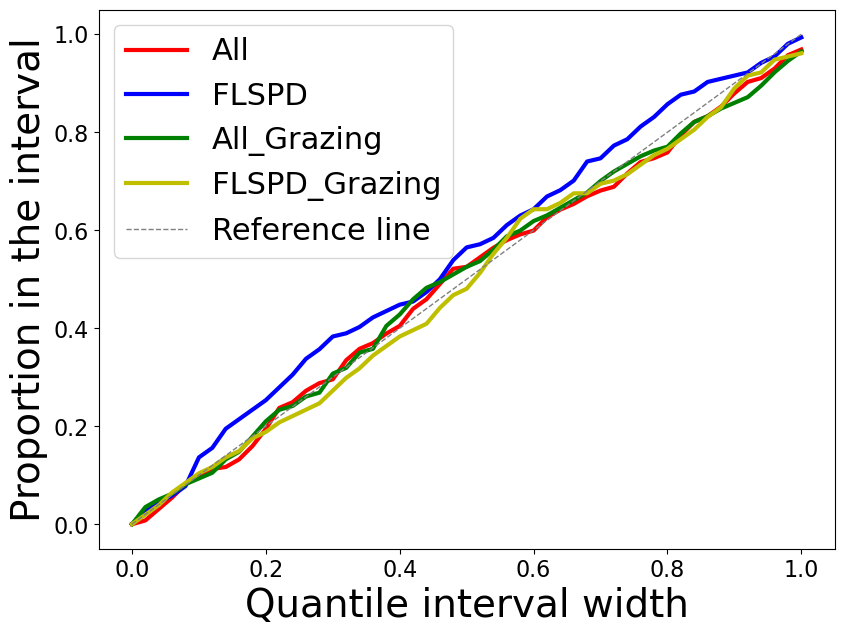

In [36]:
# Quantile random forest Portion in interval
# Initialize array to store the count of y truths in each interval
def get_count_in_the_intervals(df, quantiles):
    print(df.shape)
    df = df[(df["Gtype_inter"]=="grazing")]
    df = df.reset_index(drop=True)
    print(df.shape)
    y_truths = df['SOC (t/ha)']  # Replace with your true y values
    counts = np.zeros(len(quantiles) - 1)
    quantile_predictions = df.iloc[:,-len(quantiles):]

    num_q = len(quantiles)
    start_q = 0
    center_q = 0
    end_q = num_q-1

    #Count how many y truths fall within each quantile interval
    if ((len(quantiles)) % 2 == 0):
        center_q = len(quantiles) / 2
    else:
        center_q = (len(quantiles) + 1) / 2

    interval_list_sabine_graz = []
    portion_list_sabine_graz = []

    for i in range(0, int(center_q)):
        print("====")
        print(f"start is {start_q} quantile is {quantiles[start_q]}, end is {end_q}, quantile is {quantiles[end_q]}")

        lower_bound = quantile_predictions.iloc[:, start_q]
        upper_bound = quantile_predictions.iloc[:,  end_q]
        counts = np.sum((y_truths >= lower_bound) & (y_truths < upper_bound))

        # Calculate the portion for each interval (relative to the total count)
        total_count = len(y_truths)
        portion = counts / total_count
        interval = quantiles[end_q] - quantiles[start_q]
        print(f"interval is {interval}, portion is {portion}")

        start_q += 1
        end_q -= 1
        interval_list_sabine_graz.append(interval)
        portion_list_sabine_graz.append(portion)

    return interval_list_sabine_graz, portion_list_sabine_graz


df_quatile = pd.read_csv("03_nestedCV_prediction_all.csv")
quantiles = np.arange(0, 1.01, 0.01).tolist()
interval_all, portion_all = get_count_in_the_intervals(df=df_quatile, quantiles=quantiles)
print("**************************************************")

df_quatile = pd.read_csv("03_nestedCV_prediction_all_grazing.csv")
quantiles = np.arange(0, 1.01, 0.01).tolist()
interval_all_grazing, portion_all_grazing = get_count_in_the_intervals(df=df_quatile, quantiles=quantiles)
print("**************************************************")

df_quatile = pd.read_csv("03_nestedCV_prediction_sabine.csv")
quantiles = np.arange(0, 1.01, 0.01).tolist()
interval_sabine, portion_sabine = get_count_in_the_intervals(df=df_quatile, quantiles=quantiles)
print("**************************************************")

df_quatile = pd.read_csv("03_nestedCV_prediction_sabine_grazing.csv")
quantiles = np.arange(0, 1.01, 0.01).tolist()
interval_sabine_grazing, portion_sabine_grazing = get_count_in_the_intervals(df=df_quatile, quantiles=quantiles)
print("**************************************************")

plt.figure(figsize=(9.5, 7))
plt.plot(interval_all, portion_all, color='r', linestyle='-', linewidth=3, markersize=8, label=f"All")
plt.plot(interval_sabine, portion_sabine,color='b',linestyle='-', linewidth=3, markersize=8, label=f"FLSPD")
plt.plot(interval_all_grazing, portion_all_grazing, color='g',linestyle='-', linewidth=3, markersize=8, label=f"All_Grazing")
plt.plot(interval_sabine_grazing, portion_sabine_grazing,color='y',linestyle='-', linewidth=3, markersize=8, label=f"FLSPD_Grazing")
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16) 
plt.yticks(fontsize=16)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label="Reference line")
plt.xlabel("Quantile interval width", fontsize=28)
plt.ylabel("Proportion in the interval",fontsize=28)
plt.legend(fontsize=22)
plt.show()

df_PIP = {
    "intercal": interval_all,
    "all": portion_all,
    "FLSPD": portion_sabine,
    "all_grazing": portion_all_grazing,
    "FLSPD_grazing": portion_sabine_grazing
}
df_PIP = pd.DataFrame(df_PIP)
df_PIP.to_csv("04_PIP.csv")


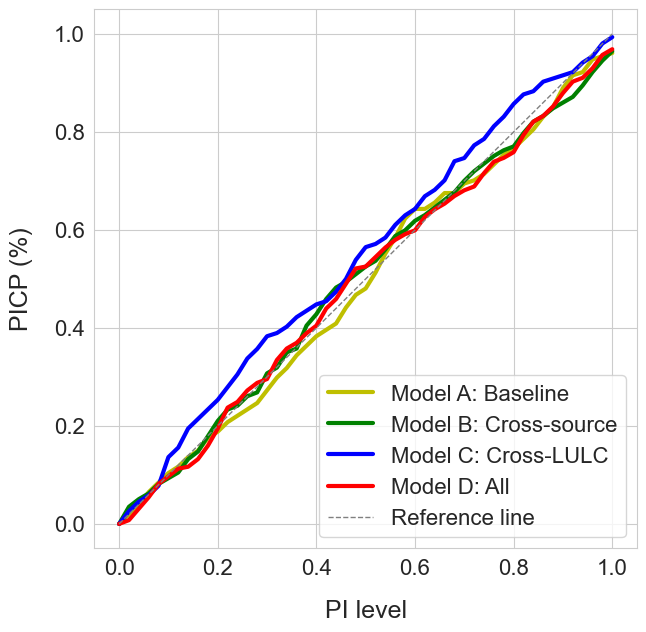

In [111]:
df_quatile = pd.read_csv("04_PIP.csv")
portion_inter = df_quatile['intercal']
interval_all = df_quatile['all']
interval_sabine = df_quatile['FLSPD']
interval_all_grazing = df_quatile['all_grazing']
interval_sabine_grazing = df_quatile['FLSPD_grazing']

plt.figure(figsize=(7, 7))
plt.plot(portion_inter, interval_sabine_grazing, color='y',linestyle='-', linewidth=3, markersize=8, label=f"Model A: Baseline")
plt.plot(portion_inter, interval_all_grazing, color='g',linestyle='-', linewidth=3, markersize=8, label=f"Model B: Cross-source")
plt.plot(portion_inter, interval_sabine, color='b',linestyle='-', linewidth=3, markersize=8, label=f"Model C: Cross-LULC")
plt.plot(portion_inter, interval_all, color='r', linestyle='-', linewidth=3, markersize=8, label=f"Model D: All")
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=16) 
plt.yticks(fontsize=16)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label="Reference line")
plt.xlabel("PI level", fontsize=18, labelpad=15)
plt.ylabel("PICP (%)",fontsize=18, labelpad=15)

plt.legend(fontsize=16, loc=4)
plt.show()

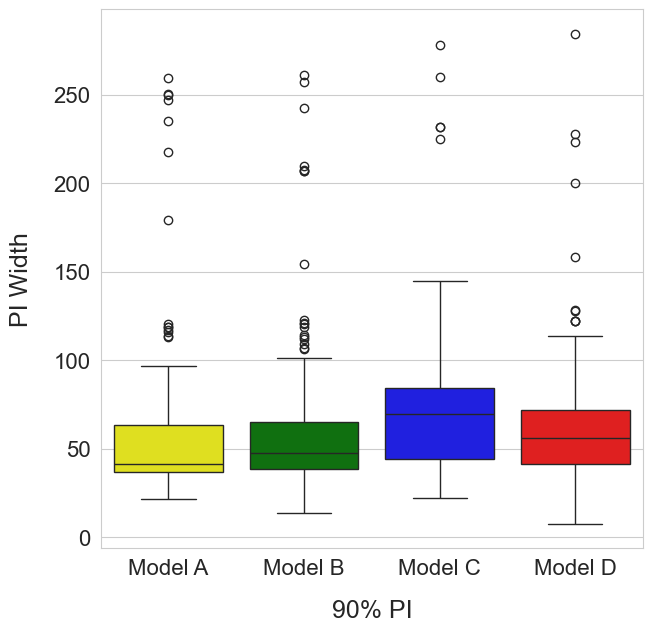

In [107]:
# anova test 

# File paths (replace these with your actual file paths)
file_paths = ["03_nestedCV_prediction_all.csv", "03_nestedCV_prediction_all_grazing.csv", "03_nestedCV_prediction_sabine.csv", "03_nestedCV_prediction_sabine_grazing.csv"]

factor_list = ["All", "All_Grazing", "FLSPD", "FLSPD_Grazing"]
# Initialize an empty list to store data
data_frames = []

q1 = 'pre_5.0th'
q2 = 'pre_95.0th'
# Read and process each CSV file
for i, file in enumerate(file_paths, start=1):
    df = pd.read_csv(file)
    df = df[(df["Gtype_inter"]=="grazing")]
    df = df.reset_index(drop=True)
    df['difference'] = df[q2] - df[q1]  # Calculate difference
    df['factor'] = factor_list[i-1]  # Add factor label
    data_frames.append(df[['difference', 'factor']])  # Keep relevant columns

# Combine all data into one DataFrame
combined_df = pd.concat(data_frames, ignore_index=True)
# Create a box plot
plt.figure(figsize=(7, 7))
custom_palette = {'All': 'red', "All_Grazing": 'green', "FLSPD": 'blue', "FLSPD_Grazing":'yellow'} 
ax = sns.boxplot(x="factor", y="difference", data=combined_df, palette=custom_palette, order=["FLSPD_Grazing", "All_Grazing", "FLSPD", "All"])
plt.xlabel("90% PI", fontsize=18, labelpad=15)
plt.ylabel(f"PI Width", fontsize=18, labelpad=15)
plt.yticks(fontsize=16)
plt.xticks(ticks=[0, 1, 2, 3], labels=["Model A", "Model B", "Model C", "Model D"], fontsize=16)
plt.show()

In [13]:
# groups
means = [np.mean(arr) for arr in groups]
[np.median(arr) for arr in groups]

[56.08210848600004, 47.482509256499995, 69.64372014900006, 41.391085915]

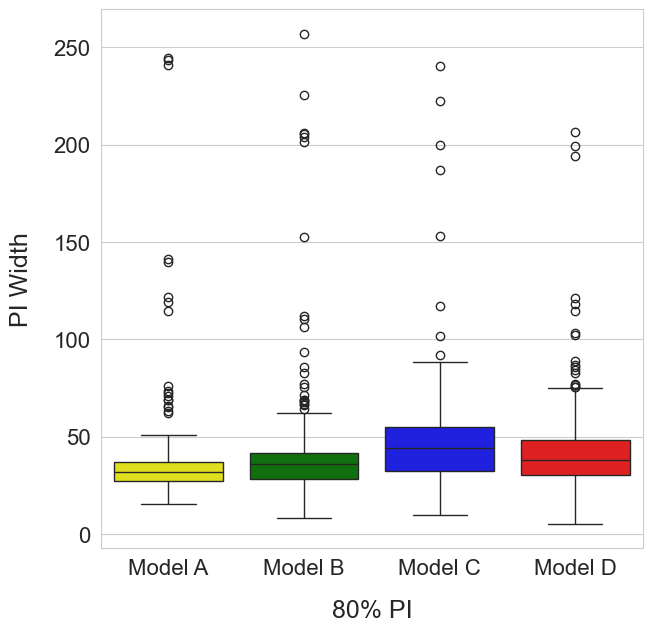

In [109]:
# anova test 

# File paths (replace these with your actual file paths)
file_paths = ["03_nestedCV_prediction_all.csv", "03_nestedCV_prediction_all_grazing.csv", "03_nestedCV_prediction_sabine.csv", "03_nestedCV_prediction_sabine_grazing.csv"]

factor_list = ["All", "All_Grazing", "FLSPD", "FLSPD_Grazing"]
# Initialize an empty list to store data
data_frames = []

q1 = 'pre_10.0th'
q2 = 'pre_90.0th'
# Read and process each CSV file
for i, file in enumerate(file_paths, start=1):
    df = pd.read_csv(file)
    df = df[(df["Gtype_inter"]=="grazing")]
    df = df.reset_index(drop=True)
    df['difference'] = df[q2] - df[q1]  # Calculate difference
    df['factor'] = factor_list[i-1]  # Add factor label
    data_frames.append(df[['difference', 'factor']])  # Keep relevant columns

# Combine all data into one DataFrame
combined_df = pd.concat(data_frames, ignore_index=True)
# Create a box plot
plt.figure(figsize=(7, 7))
custom_palette = {'All': 'red', "All_Grazing": 'green', "FLSPD": 'blue', "FLSPD_Grazing":'yellow'} 
ax = sns.boxplot(x="factor", y="difference", data=combined_df, palette=custom_palette, order=["FLSPD_Grazing", "All_Grazing", "FLSPD", "All"])
plt.xlabel("80% PI", fontsize=18, labelpad=15)
plt.ylabel(f"PI Width", fontsize=18, labelpad=15)
plt.yticks(fontsize=16)
plt.xticks(ticks=[0, 1, 2, 3], labels=["Model A", "Model B", "Model C", "Model D"], fontsize=16)
plt.show()

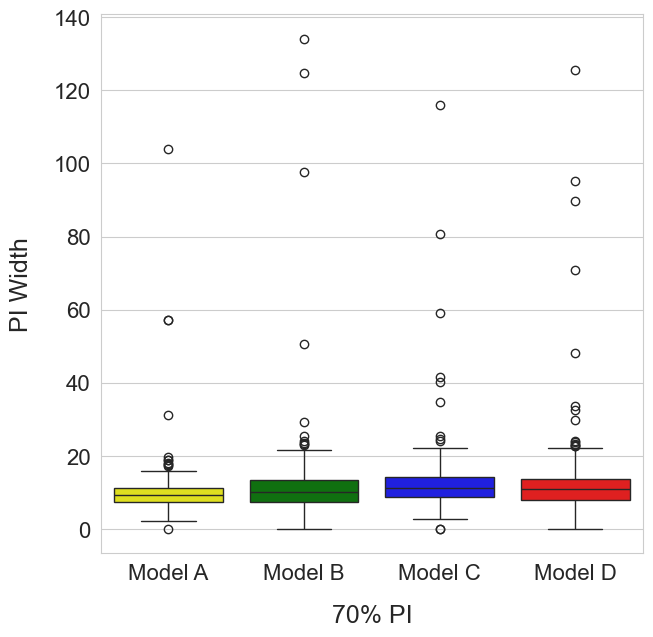

In [110]:
# anova test 

# File paths (replace these with your actual file paths)
file_paths = ["03_nestedCV_prediction_all.csv", "03_nestedCV_prediction_all_grazing.csv", "03_nestedCV_prediction_sabine.csv", "03_nestedCV_prediction_sabine_grazing.csv"]

factor_list = ["All", "All_Grazing", "FLSPD", "FLSPD_Grazing"]
# Initialize an empty list to store data
data_frames = []

q1 = 'pre_35.0th'
q2 = 'pre_65.0th'
# Read and process each CSV file
for i, file in enumerate(file_paths, start=1):
    df = pd.read_csv(file)
    df = df[(df["Gtype_inter"]=="grazing")]
    df = df.reset_index(drop=True)
    df['difference'] = df[q2] - df[q1]  # Calculate difference
    df['factor'] = factor_list[i-1]  # Add factor label
    data_frames.append(df[['difference', 'factor']])  # Keep relevant columns

# Combine all data into one DataFrame
combined_df = pd.concat(data_frames, ignore_index=True)
# Create a box plot
plt.figure(figsize=(7, 7))
custom_palette = {'All': 'red', "All_Grazing": 'green', "FLSPD": 'blue', "FLSPD_Grazing":'yellow'} 
ax = sns.boxplot(x="factor", y="difference", data=combined_df, palette=custom_palette, order=["FLSPD_Grazing", "All_Grazing", "FLSPD", "All"])
plt.xlabel("70% PI", fontsize=18, labelpad=15)
plt.ylabel(f"PI Width", fontsize=18, labelpad=15)
plt.yticks(fontsize=16)
plt.xticks(ticks=[0, 1, 2, 3], labels=["Model A", "Model B", "Model C", "Model D"], fontsize=16)
plt.show()

In [395]:
selected_feature_df = {
    "Var": sorted_feature_names,
    "Feature importance": sorted_feature_importances
}


selected_feature_df = pd.DataFrame(selected_feature_df)

selected_feature_df.to_csv("./04_feature_importance.csv")


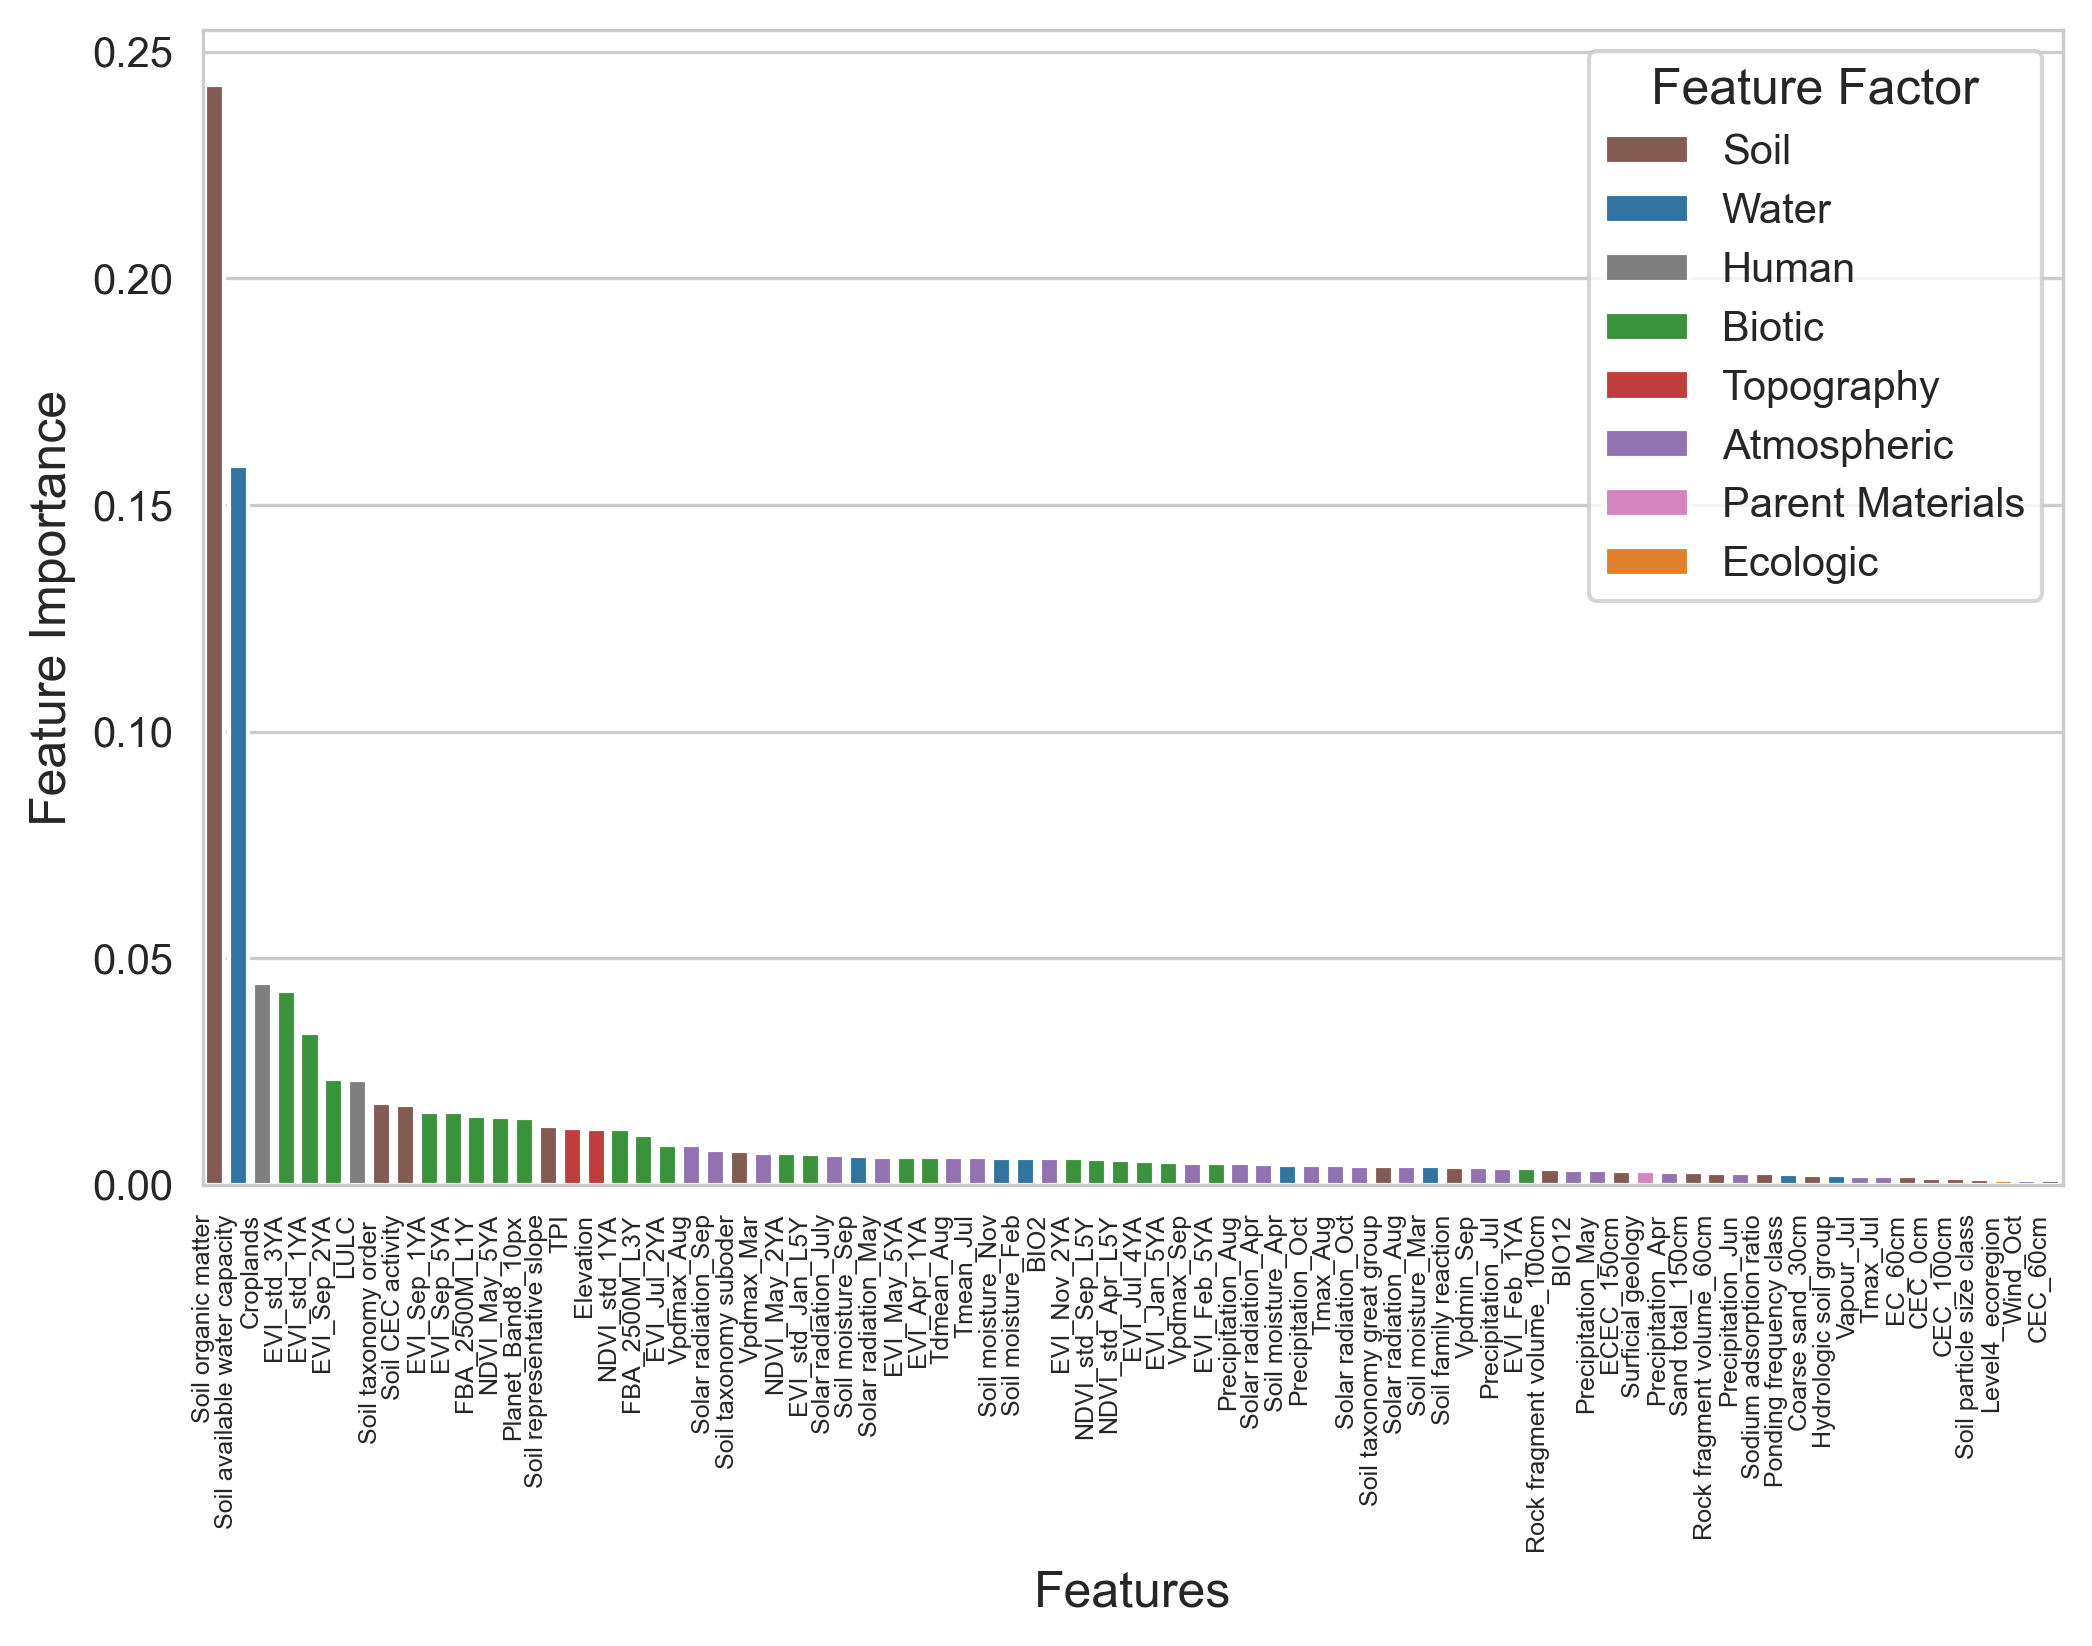

In [129]:
df = pd.read_csv("./04_feature_importance.csv")
# Sort features by importance for better visualization
df = df.sort_values("Feature importance", ascending=False)

custom_palette = {
    "Soil": "#8c564b",   # Brown
    "Topography": "#d62728",   # Red
    "Ecologic": "#ff7f0e",         # Orange
    "Parent Materials":  "#e377c2",    # Pink 
    "Atmospheric": "#9467bd",        # Purple
    "Water": "#1f77b4",      # Blue
    "Biotic": "#2ca02c",   # Green
    "Human": "#7f7f7f" # gray
}

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
# Plot feature importance with hue from "Factor"
sns.barplot(x="Features", y="Feature importance", hue="Factor", data=df, dodge=False, palette=custom_palette, ax=ax)
# Rotate X-axis labels for better readability
plt.xticks(rotation=90, ha="right", fontsize=6)

# Labels and title
plt.xlabel("Features", fontsize=12)
plt.ylabel("Feature Importance", fontsize=12)
# Show legend with original Factor names
plt.legend(title="Feature Factor", fontsize=10, title_fontsize=12)

# Show plot
plt.show()


In [3]:
# select features for all Florida prediction, based on the cumulative importance
feature_importances = pd.read_csv("./04_feature_importance.csv")
cumulative_importance = feature_importances['Feature importance'].cumsum()
print(cumulative_importance)
selected_features = feature_importances[cumulative_importance <= 0.80]['Var']
selected_features


0     0.242673
1     0.401292
2     0.445840
3     0.488718
4     0.522188
        ...   
73    0.995256
74    0.996625
75    0.997816
76    0.998958
77    1.000000
Name: Feature importance, Length: 78, dtype: float64


0                           Lookup_Organic_Matter
1     Lookup_Available_Water_Capacity_0_to_150_cm
2                                   cropLandcover
3                                    evi_2005_std
4                                    evi_2007_std
5                                     evi_2006-09
6                                       landcover
7                       Lookup_Soil_Taxnomy_Order
8                                      Lookup_CEC
9                                     evi_2007-09
10                                    evi_2003-09
11                                  Fire_2500M_1Y
12                                   ndvi_2003-05
13                                band_8_buffer10
14                    Lookup_Representative_Slope
15                                        tpi_10m
16                                  elevation_10m
17                                  ndvi_2007_std
18                                  Fire_2500M_3Y
19                                    evi_2006-07
